In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import Any, Dict
from langgraph.graph import MessagesState

class AgentState(MessagesState):
    input: str 
    pending_action: Dict[str, Any] 
    action_response: Dict[str, Any]


In [3]:
import chromadb

client = chromadb.PersistentClient(path="data/chroma")
collection = client.get_collection(
    name="parcel_pilot_docs"
)

def search_docs(query: str, k: int = 3) -> list[dict]:
    results = collection.query(
        query_texts=[query],
        n_results=k
    )

    documents = results["documents"][0]
    metadatas = results["metadatas"][0]
    distances = results["distances"][0]

    return [
        {
            "text": document,
            "metadata": metadata,
            "distance": distance 
        }
        for document, metadata, distance in zip(documents, metadatas, distances)
    ]

In [4]:
from langchain.tools import tool 

@tool
def search_docs_tool(query: str) -> str:
    """
    Search the Parcel Pilot documentation for information relevant
    to the user's question.

    Use this tool whenever the answer requires information from
    the internal documentation.
    """

    results = search_docs(query, k=3)

    if not results:
        return "No relevant documentation was found."

    formatted_results = []

    for i, result in enumerate(results, start=1):
        metadata = result["metadata"]
        source = metadata.get("source", "Unknown")
        section = metadata.get("section")
        page = metadata.get("page")

        location = section or (
            f"Page {page}" if page is not None else "Unknown location"
        )

        formatted_results.append(
            f"""
            Result {i}
            Source: {source}
            Location: {location}

            {result['text']}
            """
        )

        return "\n\n".join(formatted_results)

In [5]:
from graphs.structured_data.graph import structured_data_graph
from graphs.structured_data.schema import StructuredDataState

@tool 
def query_structured_data(instruction: str) -> str:
    """
    Query ParcelPilot's structured operational database.

    Use this tool for questions requiring:
    - account information
    - order information
    - ticket information
    - relationships between accounts, orders, and tickets
    - filtering or aggregating operational records
    - counts, totals, averages, or other calculations
    - time-based analysis of operational data

    Do NOT use this tool for:
    - policies or SOPs
    - customer contract terms
    - product documentation
    - general knowledge

    Provide an explicit instruction describing exactly what
    information you need.

    The tool is read-only and cannot modify the database.
    """

    initial_state: StructuredDataState = {
        "instruction": instruction,
        "messages": [],
    }

    result = structured_data_graph.invoke(initial_state)

    messages = result.get("messages", [])

    if not messages:
        return "The strucutured data query returned no response."

    return messages[-1].content


In [6]:
from datetime import datetime
from zoneinfo import ZoneInfo


DATASET_REFERENCE_TIME = datetime(2026, 8, 16, 11, 0, 0, tzinfo=ZoneInfo("Asia/Kolkata"))

In [7]:
# from datetime import datetime
# from typing import Optional
# import uuid

# from graphs.structured_data.database import get_connection


# @tool 
# def create_follow_up_task(
#     title: str, 
#     description: str,
#     priority: str,
#     assigned_team: str,
#     ticket_id: Optional[str] = None,
#     order_id: Optional[str] = None,
# ) -> str:
#     """
#     Create a follow-up task for ParcelPilot support or operations.

#     Use this only after the user has explicitly confirmed that
#     the task should be created.
#     """
#     priority = priority.upper()

#     allowed_priorities = ["LOW", "MEDIUM", "HIGH", "URGENT"]
#     if priority not in allowed_priorities:
#         raise ValueError(f"Invalid priority: {priority}. Allowed priorities are: {allowed_priorities}")

#     task_id = f"TASK-{uuid.uuid4().hex[:8].upper()}"
#     connection = get_connection()

#     try:
#         connection.execute(
#             """
#             INSERT INTO follow_up_tasks (
#                 task_id,
#                 title,
#                 description,
#                 priority,
#                 assigned_team,
#                 status,
#                 ticket_id,
#                 order_id,
#                 created_at 
#             )
#             VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
#             """,
#             (
#                 task_id,
#                 title,
#                 description,
#                 priority,
#                 assigned_team,
#                 "OPEN",
#                 ticket_id,
#                 order_id,
#                 DATASET_REFERENCE_TIME
#             )
#         )

#         connection.commit() 

#     finally:
#         connection.close()

#     return f"Follow-up task created successfully: {task_id}. Priority: {priority}. Assigned to: {assigned_team}."

In [8]:
import json
from typing import Literal, Optional
from langchain.tools import tool 

@tool 
def create_follow_up_task(
    title: str, 
    description: str,
    priority: Literal["LOW", "MEDIUM", "HIGH", "URGENT"],
    assigned_team: str,
    ticket_id: Optional[str] = None,
    order_id: Optional[str] = None,
) -> Dict[str, Any]:
    """
    Propose a follow-up task.

    This does NOT create the task in the database.
    The task must be approved by a human before execution.
    """

    return json.dumps({
        "title": title,
        "description": description,
        "priority": priority,
        "assigned_team": assigned_team,
        "ticket_id": ticket_id,
        "order_id": order_id,
    })

In [9]:
from data.database import get_connection

def create_task_in_database(
    title: str,
    description: str,
    priority: str,
    assigned_team: str,
    ticket_id: Optional[str] = None,
    order_id: Optional[str] = None,
) -> str:
    """
    Create a follow-up task in the database.
    
    """
    connection = get_connection()

    try:
        cursor = connection.execute(
            """
            INSERT INTO follow_up_tasks (
                title,
                description,
                priority,
                assigned_team,
                status,
                ticket_id,
                order_id,
                created_at 
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """,
            (
                title,
                description,
                priority,
                assigned_team,
                "OPEN",
                ticket_id,
                order_id,
                DATASET_REFERENCE_TIME
            )
        )

        connection.commit()

        return cursor.lastrowid

    finally:
        connection.close()


In [10]:
all_tools = [search_docs_tool, query_structured_data, create_follow_up_task]
read_tools = [search_docs_tool, query_structured_data] 

In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI

# model = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
# )

model = ChatOpenAI(
    model="gpt-5.6-luna",
    reasoning_effort="none"
)
llm = model.bind_tools(all_tools)

In [12]:
from langgraph.graph import END
from langgraph.types import Command, interrupt
from langchain_core.messages import HumanMessage

APPROVAL_WORDS = {"yes", "approve", "approved", "confirm"}

def human_node(state: AgentState):
    human_input = interrupt("Please enter your input: ")

    return {"messages": [HumanMessage(content=human_input, name="human")]}

In [13]:
def route_human(state: AgentState) -> Literal[END, "perform_action", "agent"]:
    human_input = state.get("messages", [])[-1].content

    if human_input.strip().lower() == "exit":
        return END 

    if state.get("pending_action"):
        normalized = human_input.strip().lower()

        if normalized in APPROVAL_WORDS:
            return "perform_action" 

    return "agent"

In [14]:
AGENT_SYSTEM_PROMPT = """
You are ParcelPilot's internal Support & Operations Agent.

Use the available tools to answer requests. Do not guess or rely on
general knowledge when ParcelPilot data can be retrieved.

Tools:

1. search_docs
Use for information contained in ParcelPilot documents, including:
- Policies and SOPs
- Customer-specific agreements
- Product documentation
- Cancellation and service-credit rules

2. query_structured_data
Use for structured operational data, including:
- Accounts
- Orders
- Tickets
- Filtering, aggregation, and calculations
- Relationships between accounts, orders, and tickets

3. create_follow_up_task
Use when a support or operations issue requires a follow-up task.

The tool creates and returns a task proposal. It does not immediately
execute the action.

After calling the tool:
- Display the proposed task details to the user.
- Ask the user to either approve, reject, or provide edits to the proposal.
- If the user provides edits, update the proposal and present the revised
  proposal for approval.
- Do not assume the task was created until the system confirms execution.

Use search_docs for policies, SOPs, agreements, and product documentation.
Use query_structured_data for operational facts such as accounts, orders,
and tickets.

Treat structured data as the source of truth for current operational state.

Treat customer agreements as authoritative for customer-specific terms.
Current policies and SOPs are authoritative for general rules.
Deprecated policies are historical and should not override current rules.
Historical ticket resolutions are context only and may be incorrect.

When answering a question that requires both operational facts and policy
interpretation, use both tools and combine their results.

Always use the appropriate tool for ParcelPilot-specific questions.
For questions requiring multiple sources, use multiple tools.

Customer-specific agreements may override general policies. Current
policies take precedence over deprecated policies, and historical
ticket resolutions should only be treated as context.

If the available information is insufficient to answer confidently,
state that clearly rather than guessing.
"""

In [15]:
from langchain_core.messages import AIMessage, SystemMessage 

def agent_node(state: AgentState):
    message_history = state.get('messages', [])

    messages = [
        SystemMessage(content=AGENT_SYSTEM_PROMPT),
    ] + message_history 

    response = llm.invoke(messages)

    return {
        "messages": [response]
    }



In [16]:
def process_tool_result(state: AgentState):
    last_message = state.get("messages", [])[-1]

    if last_message.name == "create_follow_up_task":
        return {
            "pending_action": {
                "action": "create_follow_up_task",
                "proposal": json.loads(last_message.content)
            }
        }

    return {}

In [17]:
def perform_action(state: AgentState): 
    action = state.get("pending_action", {})

    if not action:
        return {}

    if action["action"] == "create_follow_up_task":
        proposal = action["proposal"]

        task_id = create_task_in_database(
            title=proposal["title"],
            description=proposal["description"],
            priority=proposal["priority"],
            assigned_team=proposal["assigned_team"],
            ticket_id=proposal.get("ticket_id"),
            order_id=proposal.get("order_id"),
        )
        return {
            "pending_action": None,
            "messages": [AIMessage(content=f"Follow-up task created: {task_id}")]
        }

    return {}

In [18]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver

builder = StateGraph(AgentState) 
builder.add_node("human", human_node)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(all_tools))
builder.add_node("process_tool_result", process_tool_result)
builder.add_node("perform_action", perform_action)
builder.set_entry_point("agent")

builder.add_conditional_edges("agent", tools_condition, {"tools": "tools", "__end__": "human"})
builder.add_conditional_edges("human", route_human, {"perform_action": "perform_action", "agent": "agent", "__end__": END})
builder.add_edge("tools", "process_tool_result")
builder.add_edge("process_tool_result", "agent")
builder.add_edge("perform_action", "agent")


graph = builder.compile(checkpointer=InMemorySaver())

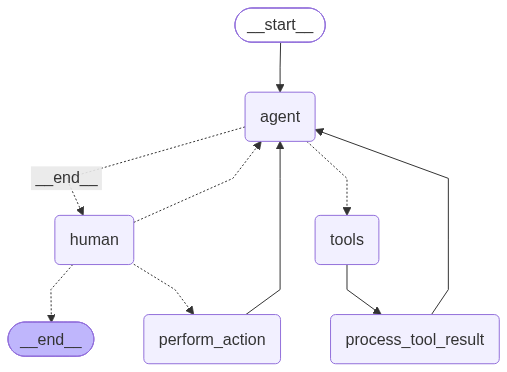

In [19]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
input = {
    "messages": [HumanMessage(content="Find all open tickets for Northstar Logistics. Then create a follow up task for the ticket that I choose.")]
}
config = {"configurable": {"thread_id": "1234"}}

output = graph.invoke(input, config)

In [21]:
output['messages'][-1].content

'Northstar Logistics has **2 open tickets**:\n\n1. **TKT-501** — All shipment creation is failing  \n   Created: 2026-08-16 10:30 | Latest update: 10:52\n\n2. **TKT-504** — SwiftShip order still shows BOOKED after driver pickup  \n   Created: 2026-08-16 10:50 | Latest update: 10:58\n\nWhich ticket should I create the follow-up task for?'

In [22]:
output2 = graph.invoke(Command(resume="Make it for TKT-501 with high priority."), config)

In [23]:
output2['messages'][-1].content

'Proposed follow-up task:\n\n- **Title:** Follow up on shipment creation failures\n- **Ticket:** TKT-501\n- **Priority:** High\n- **Assigned team:** Support Operations\n- **Description:** Investigate and follow up on Northstar Logistics ticket TKT-501 regarding all shipment creation attempts failing. Provide an update on root cause, remediation, and expected resolution timeline.\n\nPlease **approve**, **reject**, or provide edits to this proposal.'

In [24]:
output3 = graph.invoke(Command(resume="approved"), config)

/var/folders/9t/cyscz6hn76v33n2p0lx7m6wm0000gn/T/ipykernel_62938/2467032793.py:18: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  cursor = connection.execute(


In [25]:
output3['messages'][-1].content 

'The follow-up task for **TKT-501** has been approved and created successfully.'

In [26]:
output4 = graph.invoke(Command(resume="exit"), config)

In [ ]:
from pathlib import Path
import sqlite3

import pandas as pd

EXCEL_PATH = Path("data/docs/ParcelPilot_Assessment_Data.xlsx")
DB_PATH = Path("data/parcel_pilot.db")

In [ ]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def normalize_column_name(name: str) -> str:
    """Convert Excel column names to predictable SQLite column names."""
    return (
        str(name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


def to_bool(value):
    """
    Convert common Excel/Pandas boolean representations to Python bool.
    Preserve missing values as None.
    """
    if pd.isna(value):
        return None

    if isinstance(value, bool):
        return value

    value = str(value).strip().lower()

    if value in {"1", "true", "yes"}:
        return True

    if value in {"0", "false", "no"}:
        return False

    raise ValueError(f"Invalid boolean value: {value}")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize all column names."""
    df = df.copy()

    df.columns = [
        normalize_column_name(column)
        for column in df.columns
    ]

    return df

In [ ]:
# ---------------------------------------------------------------------------
# Sheet normalization
# ---------------------------------------------------------------------------

def normalize_accounts(df: pd.DataFrame) -> pd.DataFrame:
    df = normalize_columns(df)

    boolean_columns = [
        "premium_support",
    ]

    for column in boolean_columns:
        df[column] = df[column].map(to_bool)

    string_columns = [
        "account_id",
        "account_name",
        "plan",
        "status",
        "csm",
        "contract_file",
        "notes",
    ]

    for column in string_columns:
        df[column] = df[column].astype("string")

    return df


def normalize_orders(df: pd.DataFrame) -> pd.DataFrame:
    df = normalize_columns(df)

    # Boolean fields
    boolean_columns = [
        "carrier_fault",
        "customer_fault",
    ]

    for column in boolean_columns:
        df[column] = df[column].map(to_bool)

    # Datetime fields
    datetime_columns = [
        "booked_at",
        "pickup_window_start",
        "pickup_window_end",
        "pickup_actual_at",
        "cancellation_requested_at",
    ]

    for column in datetime_columns:
        df[column] = pd.to_datetime(
            df[column],
            errors="coerce",
        )

    # Numeric fields
    df["shipment_fee_inr"] = pd.to_numeric(
        df["shipment_fee_inr"],
        errors="coerce",
    )

    # String fields
    string_columns = [
        "order_id",
        "account_id",
        "carrier",
        "status",
        "notes",
    ]

    for column in string_columns:
        df[column] = df[column].astype("string")

    return df


def normalize_tickets(df: pd.DataFrame) -> pd.DataFrame:
    df = normalize_columns(df)

    # Datetime fields
    datetime_columns = [
        "created_at",
        "last_customer_message_at",
    ]

    for column in datetime_columns:
        df[column] = pd.to_datetime(
            df[column],
            errors="coerce",
        )

    # String fields
    string_columns = [
        "ticket_id",
        "account_id",
        "status",
        "subject",
        "description",
        "channel",
        "assigned_to",
        "historical_resolution",
    ]

    for column in string_columns:
        df[column] = df[column].astype("string")

    return df

In [ ]:
# ---------------------------------------------------------------------------
# README metadata
# ---------------------------------------------------------------------------

def extract_readme_metadata(
    df: pd.DataFrame,
) -> dict[str, str]:
    """
    Extract key/value metadata from the README sheet.

    The README is intentionally not treated as a normal business-data table.
    """

    metadata = {}

    # README has no normal header row.
    df = df.copy()

    for _, row in df.iterrows():

        if len(row) < 2:
            continue

        key = row.iloc[0]
        value = row.iloc[1]

        if pd.isna(key):
            continue

        key = str(key).strip()

        if pd.isna(value):
            value = ""

        metadata[key] = str(value).strip()

    return metadata

In [ ]:
# ---------------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------------

def validate_required_columns(
    df: pd.DataFrame,
    table_name: str,
    required_columns: set[str],
) -> None:

    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"{table_name} is missing required columns: "
            f"{sorted(missing)}"
        )


def validate_data(
    accounts: pd.DataFrame,
    orders: pd.DataFrame,
    tickets: pd.DataFrame,
) -> None:

    validate_required_columns(
        accounts,
        "accounts",
        {
            "account_id",
            "account_name",
            "plan",
            "status",
            "premium_support",
        },
    )

    validate_required_columns(
        orders,
        "orders",
        {
            "order_id",
            "account_id",
            "status",
            "booked_at",
            "pickup_window_start",
            "pickup_window_end",
        },
    )

    validate_required_columns(
        tickets,
        "tickets",
        {
            "ticket_id",
            "account_id",
            "created_at",
            "status",
        },
    )

    # Basic uniqueness checks
    if accounts["account_id"].duplicated().any():
        raise ValueError(
            "Duplicate account_id values found."
        )

    if orders["order_id"].duplicated().any():
        raise ValueError(
            "Duplicate order_id values found."
        )

    if tickets["ticket_id"].duplicated().any():
        raise ValueError(
            "Duplicate ticket_id values found."
        )

In [ ]:
# ---------------------------------------------------------------------------
# SQLite ingestion
# ---------------------------------------------------------------------------

def write_to_sqlite(
    db_path: Path,
    accounts: pd.DataFrame,
    orders: pd.DataFrame,
    tickets: pd.DataFrame,
    metadata: dict[str, str],
) -> None:

    # Make sure the parent directory exists.
    db_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with sqlite3.connect(db_path) as conn:

        # Business data
        accounts.to_sql(
            "accounts",
            conn,
            if_exists="replace",
            index=False,
        )

        orders.to_sql(
            "orders",
            conn,
            if_exists="replace",
            index=False,
        )

        tickets.to_sql(
            "tickets",
            conn,
            if_exists="replace",
            index=False,
        )

        # Dataset metadata
        metadata_df = pd.DataFrame(
            [
                {
                    "key": key,
                    "value": value,
                }
                for key, value in metadata.items()
            ]
        )

        metadata_df.to_sql(
            "metadata",
            conn,
            if_exists="replace",
            index=False,
        )


In [ ]:
# ---------------------------------------------------------------------------
# Schema inspection
# ---------------------------------------------------------------------------

def get_database_schema(
    db_path: Path,
) -> str:

    schema = []

    with sqlite3.connect(db_path) as conn:

        tables = pd.read_sql_query(
            """
            SELECT name
            FROM sqlite_master
            WHERE type = 'table'
            AND name NOT LIKE 'sqlite_%'
            ORDER BY name
            """,
            conn,
        )

        for table_name in tables["name"]:

            columns = pd.read_sql_query(
                f'PRAGMA table_info("{table_name}")',
                conn,
            )

            schema.append(
                f"Table: {table_name}"
            )

            for _, column in columns.iterrows():

                schema.append(
                    f"- {column['name']} "
                    f"({column['type']})"
                )

            schema.append("")

    return "\n".join(schema)

In [ ]:
# ---------------------------------------------------------------------------
# Main pipeline
# ---------------------------------------------------------------------------

def ingest_excel_to_sqlite(
    excel_path: Path,
    db_path: Path,
) -> None:

    print(f"Reading workbook: {excel_path}")

    # Read every sheet.
    sheets = pd.read_excel(
        excel_path,
        sheet_name=None,
    )

    print(
        "Sheets found:",
        list(sheets.keys()),
    )

    # -----------------------------------------------------------------------
    # README
    # -----------------------------------------------------------------------

    readme_df = sheets.get("README")

    if readme_df is None:
        raise ValueError(
            "README sheet not found."
        )

    metadata = extract_readme_metadata(
        readme_df
    )

    print("\nDataset metadata:")

    for key, value in metadata.items():
        print(f"  {key}: {value}")

    # -----------------------------------------------------------------------
    # Business data
    # -----------------------------------------------------------------------

    accounts = normalize_accounts(
        sheets["Accounts"]
    )

    orders = normalize_orders(
        sheets["Orders"]
    )

    tickets = normalize_tickets(
        sheets["Tickets"]
    )

    # -----------------------------------------------------------------------
    # Validation
    # -----------------------------------------------------------------------

    validate_data(
        accounts,
        orders,
        tickets,
    )

    # -----------------------------------------------------------------------
    # Write SQLite
    # -----------------------------------------------------------------------

    write_to_sqlite(
        db_path,
        accounts,
        orders,
        tickets,
        metadata,
    )

    print(
        f"\nSQLite database created at: {db_path}"
    )

    print("\nDatabase schema:")

    print(
        get_database_schema(db_path)
    )